In [1]:
!pip install -q xgboost

In [2]:
# ===== CELL 2: imports =====
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

sns.set(style="whitegrid")


os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [3]:
# ===== CELL 3: cargar datos =====
df = pd.read_csv("colorado_final.csv")
df = df.copy()   # evitar modificaciones sobre el original accidentalmente
df


,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,log_price
0,single_family,NaN,Beautifully maintained and spacious brick ranc...,479000,2492.0,1.0,4.0,3.0,1.0,2.0,2.0,13.079456
1,single_family,NaN,"$150, 000 PRICE CUT! And it still comes with a...",425000,3140.0,3.0,4.0,5.0,4.0,4.0,1.0,12.959844
2,single_family,NaN,Located on a quiet cul-de-sac in the desirable...,390000,2132.0,1.0,4.0,2.0,2.0,2.0,2.0,12.873902
3,townhomes,townhouse,Welcome to this beautiful townhome in Ridgevie...,375000,1615.0,2.0,3.0,3.0,1.0,2.0,2.0,12.834681
4,single_family,NaN,The mountains are calling... and you can actua...,840000,4462.0,2.0,4.0,3.0,2.0,3.0,3.0,13.641157
...,...,...,...,...,...,...,...,...,...,...,...,...
4009,single_family,NaN,"The Crescent Plan offers 1,921 square feet of ...",656114,1921.0,3.0,3.0,3.0,2.0,2.0,2.0,13.394090
4010,single_family,NaN,This open-concept floorplan is the perfect spo...,520990,2013.0,2.0,3.0,3.0,2.0,2.0,2.0,13.163486
4011,single_family,NaN,A Rare Find! This charming single-family home-...,352500,1550.0,1.0,3.0,2.0,2.0,2.0,2.0,12.772806
4012,single_family,NaN,Discover this must-see Noble home. Included fe...,524950,1670.0,1.0,3.0,2.0,2.0,2.0,2.0,13.171058


In [4]:
# ===== CELL 4: limpieza básica y features numéricos =====
# Forzar tipos numéricos y eliminar filas inválidas para las columnas clave
df['sqft'] = pd.to_numeric(df.get('sqft'), errors='coerce')
df['listPrice'] = pd.to_numeric(df.get('listPrice'), errors='coerce')
df = df.dropna(subset=['sqft', 'listPrice'])
df = df[df['sqft'] > 0].reset_index(drop=True)

# crear price_per_sqft (solo una vez) y log_price si no existe
df['price_per_sqft'] = df['listPrice'] / df['sqft']
if 'log_price' not in df.columns:
    df['log_price'] = np.log(df['listPrice'])


In [13]:
# ===== CELL 5: funciones de visualización reutilizables =====


def save_plot(name):
    # limpiar nombre del archivo
    safe_name = re.sub(r"[^\w\s-]", "", name).strip().lower()
    safe_name = re.sub(r"\s+", "_", safe_name)

    plt.savefig(f"outputs/figures/{safe_name}.png",
                dpi=300,
                bbox_inches="tight")
    
def plot_hist(series, title, xlabel, bins=30):
    plt.figure(figsize=(10,6))
    sns.histplot(series, bins=bins, kde=True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    save_plot(title)
    plt.show()

def plot_reg(x, y, data, title, xlabel, ylabel):
    plt.figure(figsize=(10,6))
    sns.regplot(x=x, y=y, data=data, scatter_kws={"alpha":0.3})
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel)
    save_plot(title)
    plt.show()

def bar_from_group(df, col, target='listPrice', agg='mean', title="BARCHAR"):
    grp = df.groupby(col)[target].mean().sort_values()
    plt.figure(figsize=(10,6))
    grp.plot(kind='bar')
    plt.title(title or f'{agg.title()} {target} by {col}')
    plt.xlabel(col); plt.ylabel(target)
    save_plot(title)
    plt.show()



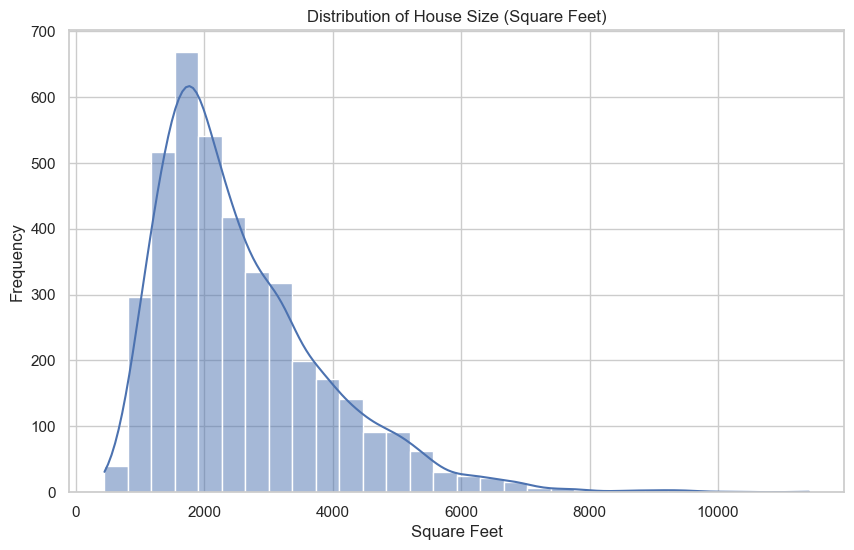

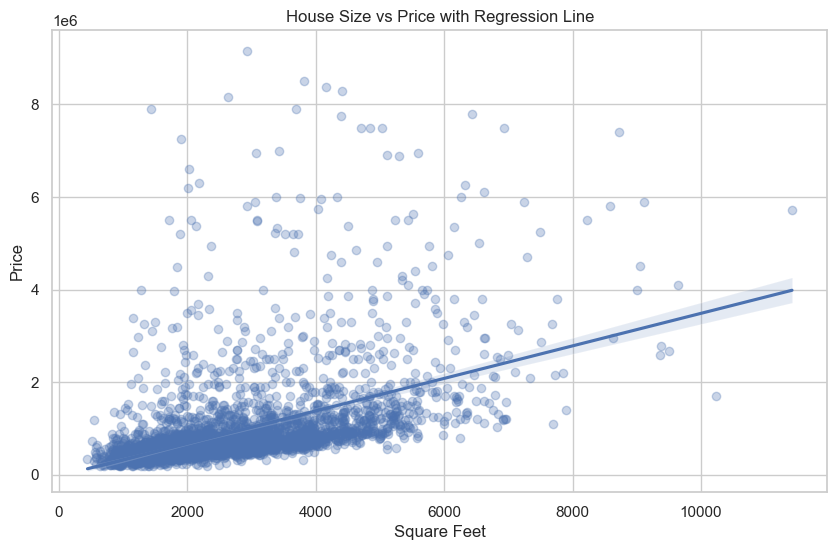

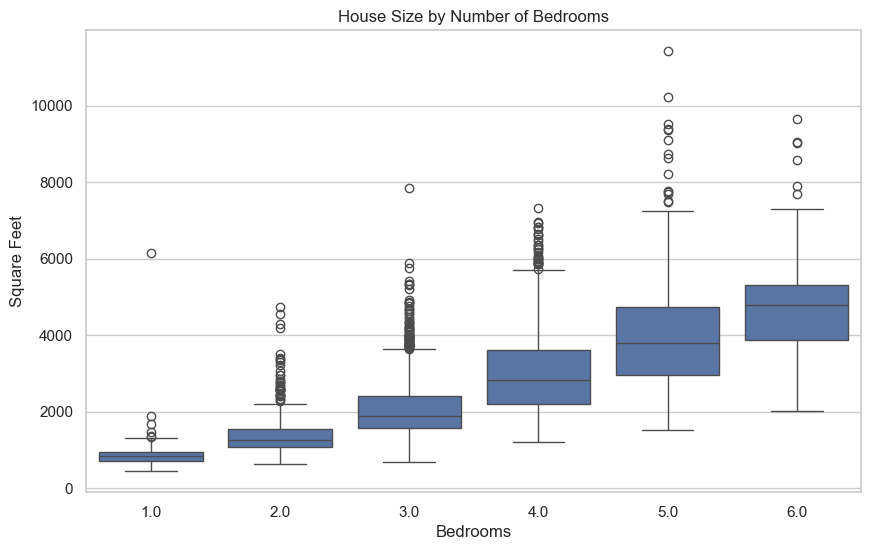

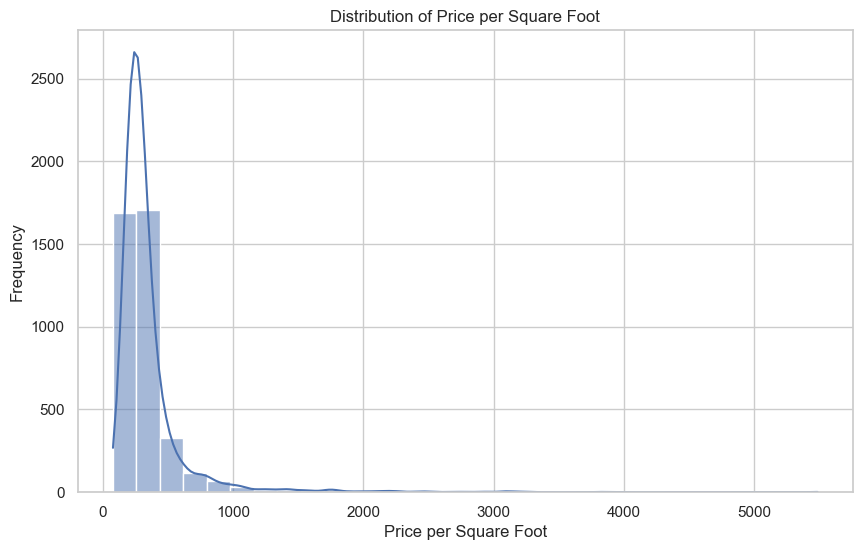

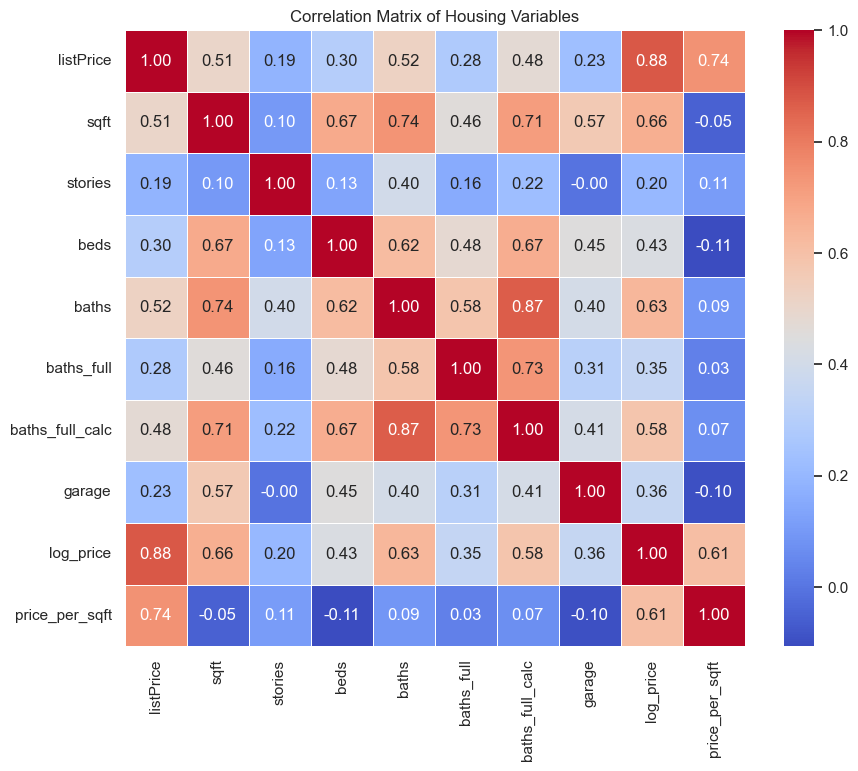

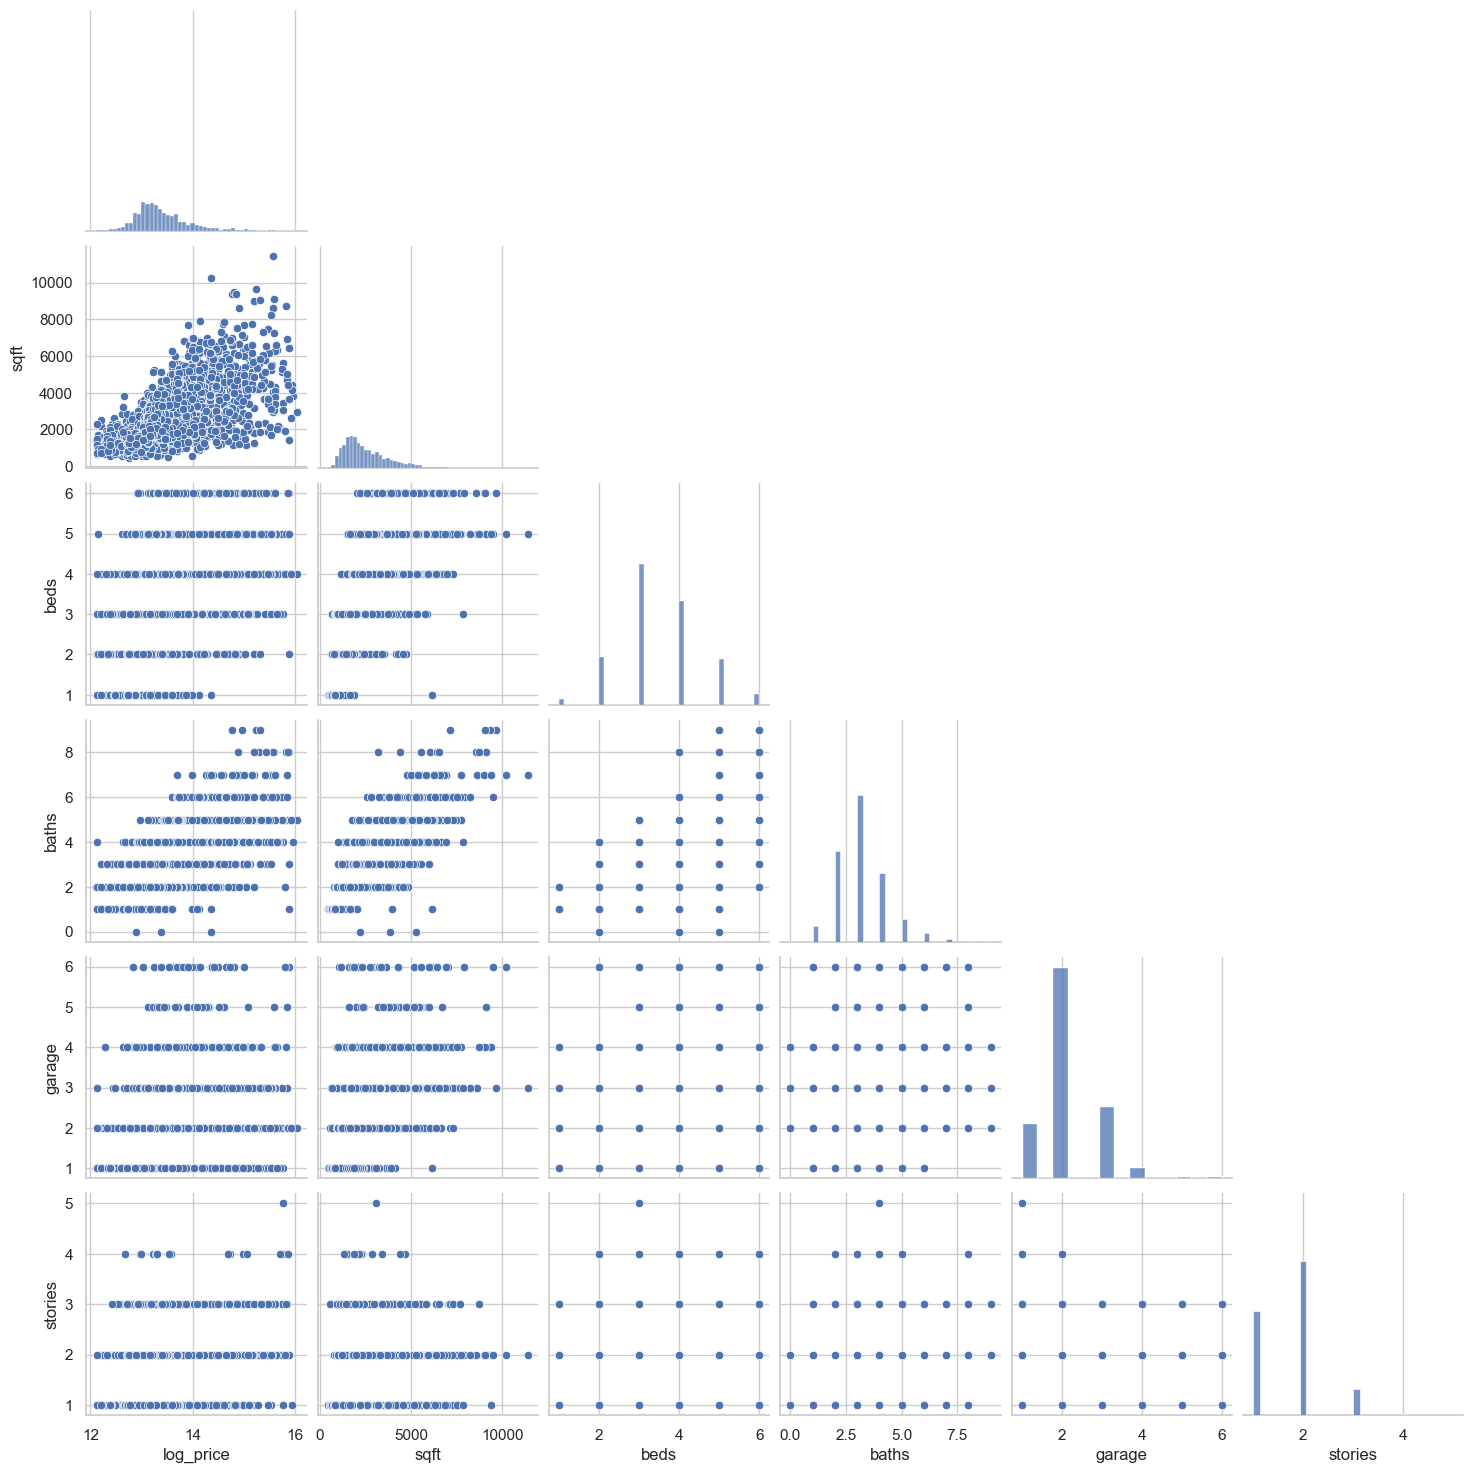

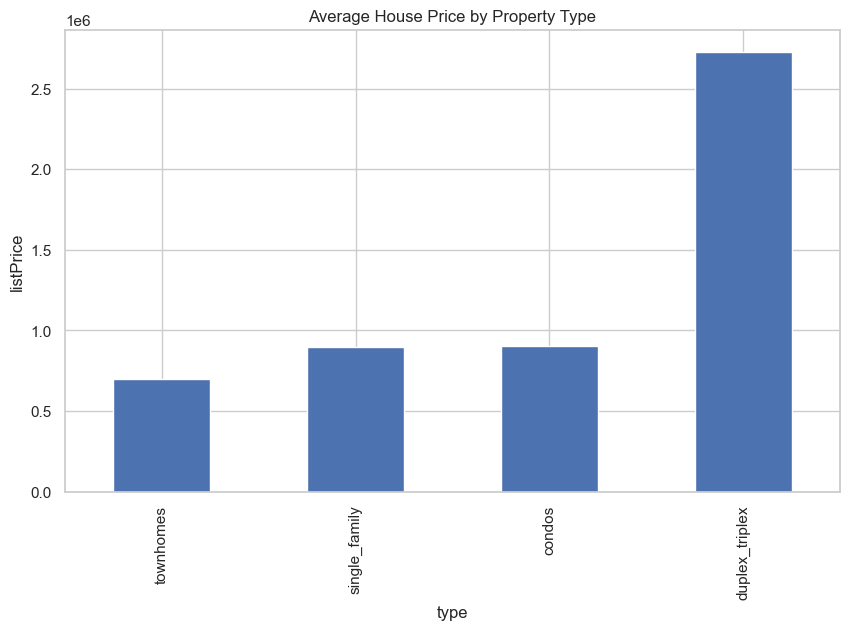

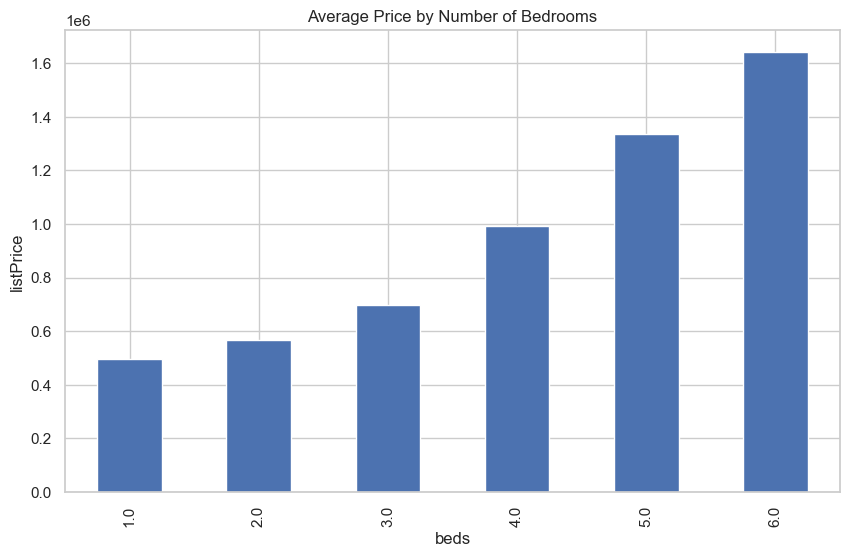

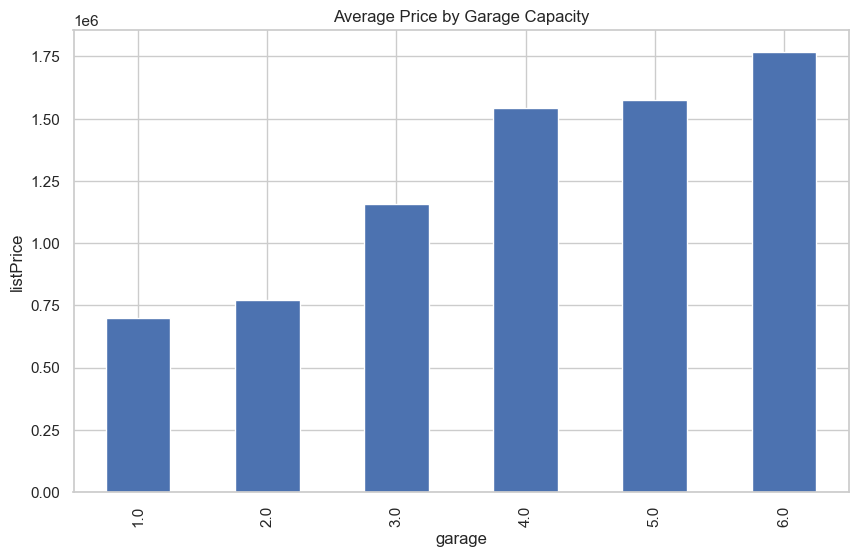

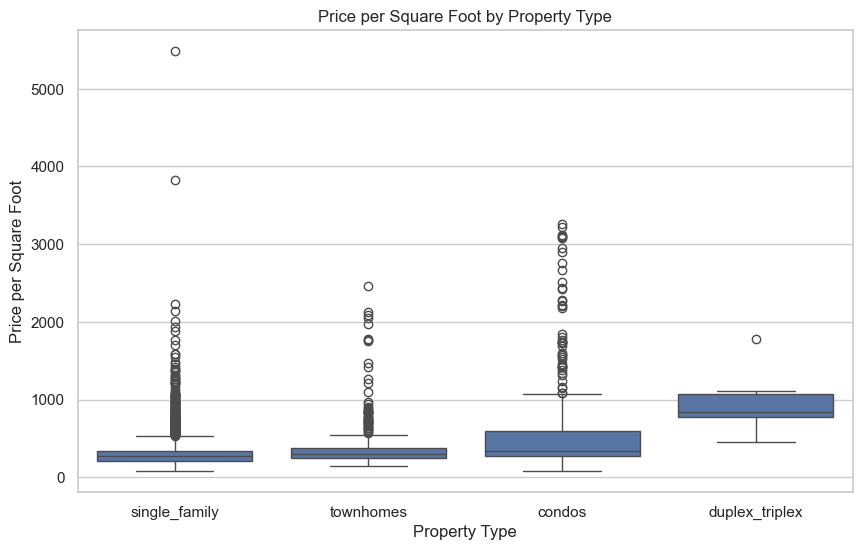

In [15]:

# ===== CELL 6: EDA (plots principales) =====
plot_hist(df['sqft'], "Distribution of House Size (Square Feet)", "Square Feet")
plot_reg("sqft", "listPrice", df, "House Size vs Price with Regression Line", "Square Feet", "Price")

if 'beds' in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='beds', y='sqft', data=df)
    plt.title("House Size by Number of Bedrooms"); plt.xlabel("Bedrooms"); plt.ylabel("Square Feet")
    save_plot("House Size by Number of Bedrooms")
    plt.show()

plot_hist(df['price_per_sqft'], "Distribution of Price per Square Foot", "Price per Square Foot")

# Correlation heatmap (solo numéricas)
num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Housing Variables")
save_plot("Correlation Matrix of Housing Variables")
plt.show()

# Pairplot si existen las variables
vars_plot = [v for v in ["log_price","sqft","beds","baths","garage","stories"] if v in df.columns]
if len(vars_plot) >= 2:
    sns.pairplot(df[vars_plot], diag_kind="hist", corner=True)
    save_plot("Pairplot General")
    plt.show()

# Agrupaciones simples
if 'type' in df.columns:
    bar_from_group(df, 'type', 'listPrice', 'mean', 'Average House Price by Property Type')
if 'beds' in df.columns:
    bar_from_group(df, 'beds', 'listPrice', 'mean', 'Average Price by Number of Bedrooms')
if 'garage' in df.columns:
    bar_from_group(df, 'garage', 'listPrice', 'mean', 'Average Price by Garage Capacity')

if 'type' in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x='type', y='price_per_sqft', data=df)
    plt.title("Price per Square Foot by Property Type"); plt.xlabel("Property Type"); plt.ylabel("Price per Square Foot")
    plt.show()

In [16]:

# ===== CELL 7: extracción de features de texto (compacta, sin repeticiones) =====
text = df.get('text', pd.Series("")).fillna("").str.lower()

# Diccionario de grupos con patrones (puedes ampliar)

groups = {
    "view_feature": [
        "views", "view", "mountain views", "mountain", "water", "lake view", "ocean"
    ],
    # Calidad / segmento premium
    "luxury_finish": [
        "luxury", "premium", "custom", "high-end", "upgraded", "upgraded finishes",
        "finishes", "granite countertops", "quartz countertops",
        "stainless steel appliances", "stainless steel", "island", "countertops",
        "luxury vinyl plank", "custom finishes"
    ],

    # Propiedades recientemente renovadas / modernizadas
    "recently_renovated": [
        "renovated", "updated", "brand new", "new", "modern", "fully renovated",
        "updated finishes", "newly", "move-in ready", "ready"
    ],

    # Layout y diseño: apertura y flujo (valor por estilo)
    "open_layout": [
        "open floor plan", "open concept", "open concept layout", "open space",
        "open concept living", "open concept kitchen", "open"
    ],

    # Suite principal / master suite quality (walk-in closets, en suite)
    "primary_suite": [
        "primary suite", "primary bedroom", "primary suite offers",
        "primary suite includes", "spacious primary suite", "en suite",
        "en suite bathroom", "en suite bath", "walk closet", "large walk closet",
        "spacious walk closet", "walk-in closet", "walk closet additional"
    ],

    # Cocina / electrodomésticos y acabados de cocina (predictivo aparte de sqft)
    "kitchen_highend": [
        "stainless steel appliances", "steel appliances", "stainless",
        "quartz countertops", "granite countertops", "countertops stainless steel",
        "island", "kitchen island", "appliances", "countertops"
    ],

    # Vistas y localización premium (views)
    "views": [
        "views", "mountain views", "mountain", "panoramic view", "ocean view",
        "lake view", "water view", "mountain view"
    ],

    # Espacio exterior / outdoor living (patio, deck, backyard)
    "outdoor_space": [
        "backyard", "patio", "covered patio", "deck", "outdoor living", "outdoor",
        "yard", "garden", "covered", "outdoor living"
    ],

    # Chimenea / ambientación (puede incrementar valor en climas fríos)
    "fireplace": [
        "fireplace", "gas fireplace", "wood burning fireplace", "cozy gas fireplace"
    ],

    # Basement terminado (acrescenta superficie funcional)
    "finished_basement": [
        "finished basement", "fully finished basement", "finished", "basement",
        "lower level", "fully finished"
    ],

    # Garage / parking de valor (oversized, attached)
    "parking_premium": [
        "oversized", "oversized car garage", "oversized garage", "attached car garage",
        "attached garage", "car garage", "car attached garage", "garage attached", "garage"
    ],

    # Almacenamiento / closets más allá del simple closet
    "storage_walkin": [
        "storage", "closet", "walk closet", "walk-in closet", "storage space",
        "large walk closet", "generous walk closet", "oversized storage"
    ],

    # Home office / espacios para teletrabajo
    "home_office": [
        "home office", "office", "guests home office", "office space", "study"
    ],

    # Comodidades comunitarias / conveniencia (parks, trails, shopping)
    "community_amenities": [
        "community", "park", "trails", "shopping", "shopping dining", "conveniently located",
        "convenience", "minutes", "just minutes"
    ],

    # Tipo/uso: ranch / single family / multi-gen
    "property_type_signals": [
        "ranch", "ranch style home", "single family home", "single family", "multi generational living",
        "multi-generational", "multi generational"
    ],

    # Low maintenance / ready to live (valor en segmentos buscados por buyers que no quieren obras)
    "low_maintenance": [
        "low maintenance", "low maintenance living", "turnkey", "move-in ready", "easy maintenance"
    ],

    # Energy / systems (tankless water heater, gas)
    "systems_energy": [
        "tankless water heater", "tankless", "gas", "gas fireplace", "gas heating"
    ]
}

# Crear columnas binarias de forma vectorizada
for name, pats in groups.items():
    pattern = "|".join(pats)
    df[name] = text.str.contains(pattern, regex=True, na=False).astype(int)

# ejemplo de otras banderas simples
# keywords = ["renovated","luxury","mountain","view","garage","new","remodeled","granite","open concept"]
# for kw in keywords:
#     col = f"kw_{kw.replace(' ','_')}"
#     df[col] = text.str.contains(re.escape(kw), case=False, na=False).astype(int)

# Mostrar prevalencia de los grupos (ayuda en selección de features)
print("Feature prevalence (proportion true):")
print(df[list(groups.keys())].mean().sort_values(ascending=False).round(3))


Feature prevalence (proportion true):
outdoor_space            0.780
community_amenities      0.749
recently_renovated       0.736
luxury_finish            0.714
open_layout              0.668
storage_walkin           0.651
parking_premium          0.649
kitchen_highend          0.616
primary_suite            0.588
view_feature             0.526
finished_basement        0.457
views                    0.396
home_office              0.379
fireplace                0.337
systems_energy           0.270
property_type_signals    0.240
low_maintenance          0.155
dtype: float64


In [24]:
# ===== CELL 8: preparar dataset para modelado =====
# Seleccionar features base y añadir flags de texto
base_numeric = ['sqft','beds','baths','garage','stories']
available = [c for c in base_numeric if c in df.columns]

# text_flags = list(groups.keys()) + [f"kw_{kw.replace(' ','_')}" for kw in keywords]
text_flags = list(groups.keys())
text_flags = [c for c in text_flags if c in df.columns]

feature_cols = available + text_flags

# incluir categoría 'type' si existe
X = df[feature_cols].copy()
if 'type' in df.columns:
    X = pd.get_dummies(pd.concat([X, df[['type']]], axis=1), drop_first=True)

# Eliminar filas con NA en X
X = X.fillna(0)

y = df['log_price']

# dividir
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
# ===== CELL 9: helpers de evaluación =====
def evaluate_model(model, X_test, y_test, print_results=True):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(np.exp(y_test), np.exp(y_pred))  # MAE in price units
    rmse = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred)))
    if print_results:
        print(f"R2 (log-scale): {r2:.4f}")
        print(f"MAE (price units): {mae:.2f}")
        print(f"RMSE (price units): {rmse:.2f}")
    return y_pred, {'r2': r2, 'mae': mae, 'rmse': rmse}

def plot_real_vs_pred(y_true_log, y_pred_log, title="Real vs Predicted House Prices"):
    plt.figure(figsize=(8,6))
    plt.scatter(np.exp(y_true_log), np.exp(y_pred_log), alpha=0.5)
    mn = min(np.exp(y_true_log).min(), np.exp(y_pred_log).min())
    mx = max(np.exp(y_true_log).max(), np.exp(y_pred_log).max())
    plt.plot([mn,mx],[mn,mx], linestyle='--')
    plt.xlabel("Real Price"); plt.ylabel("Predicted Price"); plt.title(title)
    save_plot(title)
    plt.show()

R2 (log-scale): 0.5677
MAE (price units): 253156.68
RMSE (price units): 561866.29


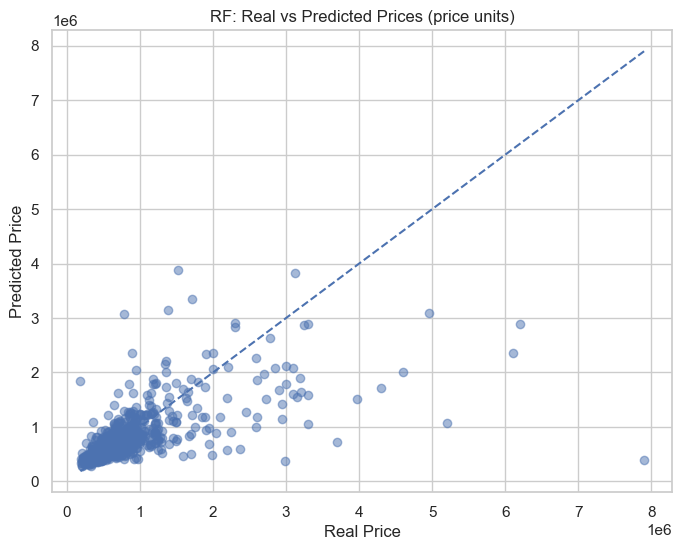

Top 15 feature importances (RF):
sqft                  0.433660
baths                 0.213501
views                 0.076345
stories               0.040477
garage                0.026460
finished_basement     0.024555
beds                  0.021444
type_single_family    0.016491
fireplace             0.013685
open_layout           0.011912
kitchen_highend       0.010961
systems_energy        0.010865
primary_suite         0.010656
parking_premium       0.010188
home_office           0.010027
dtype: float64
RF CV R2 scores: [0.6024 0.6291 0.6619 0.5738 0.5837]
RF CV R2 mean: 0.6102


In [33]:
# ===== CELL 10: RandomForest (rápido) =====
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
joblib.dump(rf, "outputs/models/random_forest_model.pkl")

# evaluación
y_pred_rf, metrics_rf = evaluate_model(rf, X_test, y_test)

# guardar métricas
results_rf = pd.DataFrame({
    "metric": ["R2", "MAE", "RMSE"],
    "value": [metrics_rf["r2"], metrics_rf["mae"], metrics_rf["rmse"]]
})

results_rf.to_csv("outputs/tables/random_forest_metrics.csv", index=False)

# grafico
plot_real_vs_pred(y_test, y_pred_rf, title="RF: Real vs Predicted Prices (price units)")

# Importancias
importance_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 15 feature importances (RF):")
print(importance_rf.head(15))

# guardar importancia
importance_rf.to_csv("outputs/tables/random_forest_feature_importance.csv")

# Validación cruzada R2 (log-scale)
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring='r2', n_jobs=-1)
print("RF CV R2 scores:", cv_scores_rf.round(4))
print("RF CV R2 mean:", cv_scores_rf.mean().round(4))

In [34]:
# ===== Número de variables en el modelo =====
obs = X.shape[0]
features = X.shape[1]

ratio = obs / features

print(f"Observations: {obs}")
print(f"Features: {features}")
print(f"Observations per feature: {ratio:.2f}")

Observations: 4012
Features: 25
Observations per feature: 160.48


R2 (log-scale): 0.5823
MAE (price units): 257337.48
RMSE (price units): 553139.75


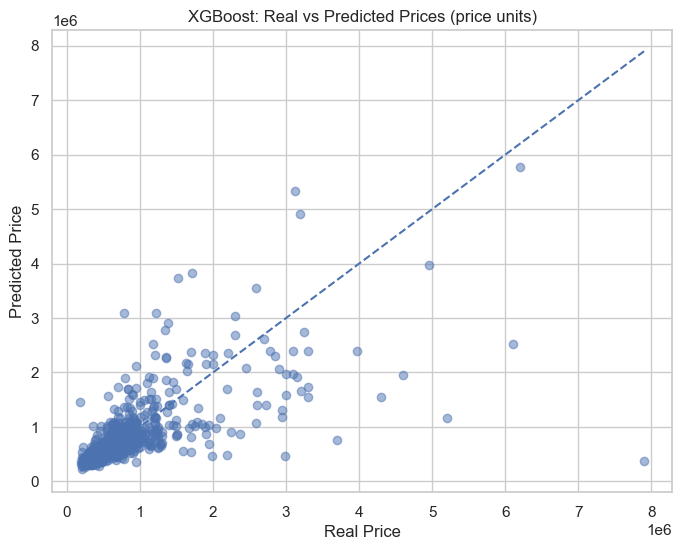

XGB CV R2 scores: [0.5898 0.6302 0.6718 0.5918 0.6407]
XGB CV R2 mean: 0.6248
Top 15 feature importances (XGB):
baths                 0.154584
views                 0.126543
sqft                  0.075691
type_single_family    0.056859
type_townhomes        0.056554
finished_basement     0.054748
stories               0.041042
view_feature          0.034276
garage                0.033462
fireplace             0.032857
beds                  0.030005
systems_energy        0.029866
open_layout           0.027160
home_office           0.024390
kitchen_highend       0.024281
dtype: float32


In [35]:
# ===== CELL 11: XGBoost (ajustado) =====
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,          # entero, no None
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
joblib.dump(xgb, "outputs/models/xgboost_model.pkl")

y_pred_xgb, metrics_xgb = evaluate_model(xgb, X_test, y_test)

# guardar métricas
results_xgb = pd.DataFrame({
    "metric": ["R2", "MAE", "RMSE"],
    "value": [metrics_xgb["r2"], metrics_xgb["mae"], metrics_xgb["rmse"]]
})
results_xgb.to_csv("outputs/tables/xgboost_metrics.csv", index=False)


plot_real_vs_pred(y_test, y_pred_xgb, title="XGBoost: Real vs Predicted Prices (price units)")

cv_scores_xgb = cross_val_score(xgb, X, y, cv=5, scoring='r2', n_jobs=-1)
print("XGB CV R2 scores:", cv_scores_xgb.round(4))
print("XGB CV R2 mean:", cv_scores_xgb.mean().round(4))

# # Importancia XGBoost (gain/weight can variar según versión)
# try:
#     feat_imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
#     print("Top 15 feature importances (XGB):")
#     print(feat_imp.head(15))
# except Exception:
#     pass

# importancia XGBoost
try:
    importance_xgb = pd.Series(
        xgb.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    print("Top 15 feature importances (XGB):")
    print(importance_xgb.head(15))

    # guardar importancia
    importance_xgb.to_csv("outputs/tables/xgboost_feature_importance.csv")

except Exception:
    pass

In [36]:
# ===== CELL 12: resultados y tabla comparativa =====
results = pd.DataFrame({
    "real_log": y_test,
    "pred_rf_log": y_pred_rf,
    "pred_xgb_log": y_pred_xgb
})
results['real_price'] = np.exp(results['real_log'])
results['pred_rf_price'] = np.exp(results['pred_rf_log'])
results['pred_xgb_price'] = np.exp(results['pred_xgb_log'])
results[['real_price','pred_rf_price','pred_xgb_price']].head(10)

,real_price,pred_rf_price,pred_xgb_price
1745,775000.0,3.071336e+06,3.088627e+06
3999,589089.0,5.652495e+05,5.735589e+05
1373,1390000.0,3.138261e+06,2.910174e+06
3964,408990.0,5.265323e+05,5.235483e+05
3531,397062.0,3.725578e+05,3.074030e+05
2005,665000.0,6.323241e+05,7.952937e+05
1533,442000.0,6.761305e+05,5.240608e+05
2486,750000.0,6.718125e+05,6.708890e+05
1754,469000.0,4.539687e+05,3.964444e+05
978,1650000.0,1.475096e+06,2.025682e+06
